# Univariate Analysis

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

* Filtering on Standard Type to get comparable types and Assay ChEMBL ID to get only inverse agonists
* Dropping null columns

In [7]:
filtered = df[(df['Standard Type'] == 'Potency') & (df['Assay ChEMBL ID'] == 'CHEMBL2114788')]
print(filtered['Standard Units'].value_counts())
print()
print(filtered.columns[filtered.isna().all()])
filtered_2 = filtered.dropna(axis=1, how='all')
print(filtered_2.info())

Standard Units
nM    103901
Name: count, dtype: int64

Index(['Standard Relation', 'pChEMBL Value', 'Data Validity Comment', 'Ligand Efficiency BEI', 'Ligand Efficiency LE', 'Ligand Efficiency LLE', 'Ligand Efficiency SEI', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name', 'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters', 'Assay Variant Accession', 'Assay Variant Mutation', 'Document Journal', 'Document Year', 'Cell ChEMBL ID', 'Properties', 'Action Type', 'Standard Text Value'], dtype='str')
<class 'pandas.DataFrame'>
Index: 103901 entries, 124 to 113031
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Molecule ChEMBL ID   103901 non-null  str    
 1   Molecule Name        549 non-null     str    
 2   Molecule Max Phase   323 non-null     float64
 3   Molecular Weight     103888 non-null  float64
 4   #RO5 Violations      103829 non-null  float64
 5   AlogP                103829

* Analyse the distribution of Standard Value

count    103901.000000
mean      14167.422775
std        9254.340557
min         112.200000
25%        7943.300000
50%       11220.200000
75%       22387.200000
max       35481.300000
Name: Standard Value, dtype: float64
0.5372476384640007
-0.9991670697391437


<Axes: xlabel='Standard Value', ylabel='Count'>

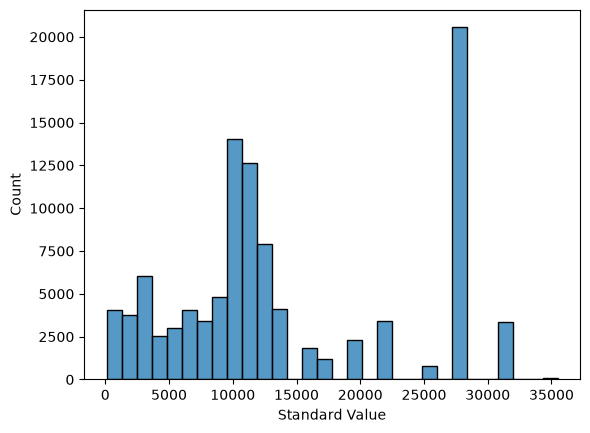

In [8]:
print(filtered_2['Standard Value'].describe())
print(filtered_2['Standard Value'].skew())
print(filtered_2['Standard Value'].kurt())
sns.histplot(filtered_2['Standard Value'], bins=30)


* Investigating the outlier bin in Standard Value histogram

In [9]:
mask = (filtered_2['Standard Value'] > 27000) & (filtered_2['Standard Value'] < 29000)
outliers = filtered_2[mask]
print(outliers['Standard Value'].value_counts(),'\n')
print(outliers.nunique(), '\n')
print(outliers['Comment'].value_counts())

Standard Value
28183.8    20546
Name: count, dtype: int64 

Molecule ChEMBL ID     20517
Molecule Name             82
Molecule Max Phase         5
Molecular Weight        8711
#RO5 Violations            4
AlogP                    753
Compound Key           20545
Smiles                 20510
Standard Type              1
Standard Value             1
Standard Units             1
Comment                    2
Uo Units                   1
Potential Duplicate        1
Assay ChEMBL ID            1
Assay Description          1
Assay Type                 1
BAO Format ID              1
BAO Label                  1
Assay Organism             1
Target ChEMBL ID           1
Target Name                1
Target Organism            1
Target Type                1
Document ChEMBL ID         1
Source ID                  1
Source Description         1
Value                      1
dtype: int64 

Comment
inconclusive    17813
inactive         2733
Name: count, dtype: int64


* Excluded 28183.8 nM values and re-running distribution analysis

count    83355.000000
mean     10712.555202
std       6811.125525
min        112.200000
25%       6309.600000
50%      10000.000000
75%      12589.300000
max      35481.300000
Name: Standard Value, dtype: float64 

Standard Value mean = 10712.56 and median = 10000.00
Standard Value skew = 1.18 and excess kurtosis = 1.87


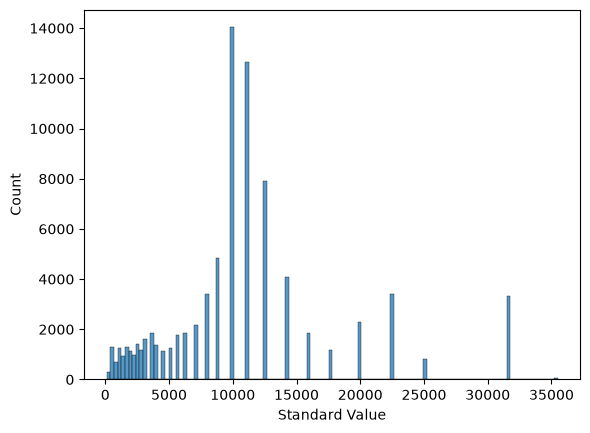

In [10]:
filtered_3 = filtered_2[filtered_2['Standard Value'] != 28183.8]
sns.histplot(filtered_3['Standard Value'])
print(filtered_3['Standard Value'].describe(), '\n')
print(f"Standard Value mean = {filtered_3['Standard Value'].mean():.2f} and median = {filtered_3['Standard Value'].median():.2f}")
print(f"Standard Value skew = {filtered_3['Standard Value'].skew():.2f} and excess kurtosis = {filtered_3['Standard Value'].kurt():.2f}")

* Are there Standard Value values that occur frequently?

In [11]:
print(filtered_3[filtered_3['Standard Value'] == 10000])
print(pd.concat([filtered_3['Standard Value'].value_counts(),
filtered_3['Standard Value'].value_counts(normalize=True)], axis=1))

       Molecule ChEMBL ID Molecule Name  Molecule Max Phase  Molecular Weight  #RO5 Violations  AlogP Compound Key                                             Smiles Standard Type  Standard Value Standard Units       Comment    Uo Units  Potential Duplicate Assay ChEMBL ID                                  Assay Description Assay Type BAO Format ID     BAO Label Assay Organism Target ChEMBL ID                       Target Name Target Organism     Target Type Document ChEMBL ID  Source ID Source Description  Value
141         CHEMBL1380864           NaN                 NaN            289.34              0.0   1.10   SID3713197                CCn1cc(C(=O)NCCOC)c(=O)c2ccc(C)nc21       Potency         10000.0             nM      inactive  UO_0000065                    0   CHEMBL2114788  PubChem BioAssay. qHTS of GLP-1 Receptor Inver...          F   BAO_0000019  assay format   Homo sapiens       CHEMBL1784  Glucagon-like peptide 1 receptor    Homo sapiens  SINGLE PROTEIN      CHEMBL1201862  

Compounds with inactive/inconclusive comments

In [12]:
print(filtered_3['Comment'].value_counts(dropna=False, normalize=True), '\n')
print(filtered_3['Comment'].value_counts(dropna=False), '\n')

print(f"Filtering to inconclusive results:")
inc_filtered = filtered_3[filtered_3['Comment'] == 'inconclusive']
print(pd.concat([inc_filtered['Standard Value'].value_counts(),
inc_filtered['Standard Value'].value_counts(normalize=True)], axis=1))

print(f"Comparison of full (filtered) set and inconclusive:")
print(pd.concat([filtered_3['Standard Value'].value_counts(normalize=True),
inc_filtered['Standard Value'].value_counts(normalize=True)], axis=1, keys=['Full set', 'inconclusive']))


Comment
inconclusive    0.743123
inactive        0.179713
active          0.077164
Name: proportion, dtype: float64 

Comment
inconclusive    61943
inactive        14980
active           6432
Name: count, dtype: int64 

Filtering to inconclusive results:
                count  proportion
Standard Value                   
10000.0         10332    0.166799
11220.2          9815    0.158452
12589.3          6404    0.103385
8912.5           3671    0.059264
14125.4          3337    0.053872
31622.8          3061    0.049416
22387.2          2776    0.044815
7943.3           2544    0.041070
19952.6          1921    0.031012
7079.5           1608    0.025959
15848.9          1449    0.023392
6309.6           1402    0.022634
3548.1           1219    0.019679
5623.4           1181    0.019066
3162.3            924    0.014917
3981.1            911    0.014707
17782.8           887    0.014320
5011.9            689    0.011123
2511.9            687    0.011091
1995.3            683    0.0110

* Filtering out 'inconclusive' results

In [13]:

conclusive_rows = filtered_3[filtered_3['Comment'] != 'inconclusive']
print(f"Conclusive rows after filtering: {conclusive_rows.shape[0]} \n")
print(f"Standard Value mean = {conclusive_rows['Standard Value'].mean():.2f} and median = {conclusive_rows['Standard Value'].median():.2f} \n")
print(f"Standard Value skew = {conclusive_rows['Standard Value'].skew():.2f} and excess kurtosis = {conclusive_rows['Standard Value'].kurt():.2f} \n")

q1 = conclusive_rows['Standard Value'].describe()['25%']
q3 = conclusive_rows['Standard Value'].describe()['75%']
iqr = q3 - q1

print(f"For conclusive results, Q1: {q1}, Q3: {q3} and interquartile range: {iqr}")

upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

print(f"Lower fence: {lower_fence:.1f}, Upper fence: {upper_fence:.1f}")

rows_under = conclusive_rows[conclusive_rows['Standard Value'] < lower_fence].shape[0]
rows_over = conclusive_rows[conclusive_rows['Standard Value'] > upper_fence].shape[0]

print(f"There are {rows_under} rows below the lower fence, and {rows_over} above the upper fence")


Conclusive rows after filtering: 21412 

Standard Value mean = 8845.67 and median = 10000.00 

Standard Value skew = 1.09 and excess kurtosis = 2.16 

For conclusive results, Q1: 3981.1, Q3: 11220.2 and interquartile range: 7239.1
Lower fence: -6877.6, Upper fence: 22078.9
There are 0 rows below the lower fence, and 1037 above the upper fence


* Investigating outliers

Standard Value
22387.2    624
31622.8    274
25118.9    135
35481.3      4
Name: count, dtype: int64


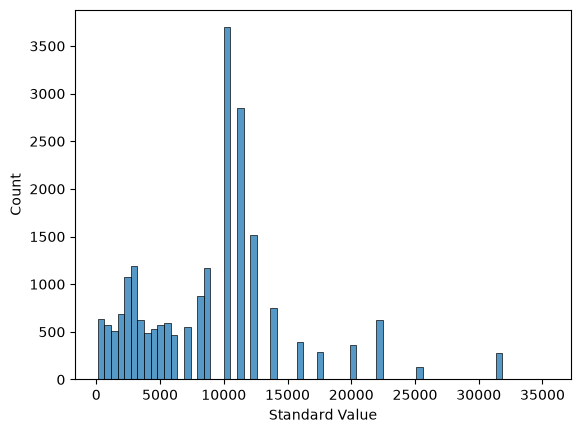

In [14]:

sns.histplot(conclusive_rows['Standard Value'])
outliers = conclusive_rows[conclusive_rows['Standard Value'] > upper_fence]
print(outliers['Standard Value'].value_counts())


* Box plot

<Axes: xlabel='Standard Value'>

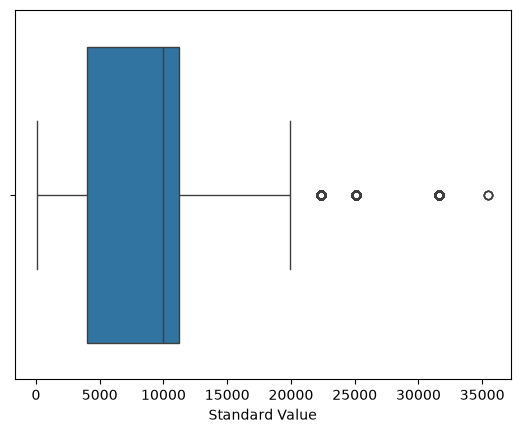

In [15]:
sns.boxplot(x=conclusive_rows['Standard Value'])